# Reading and preprocessing the data...

The dataset that we are using is taken from : https://www.kaggle.com/datasets/annavictoria/speed-dating-experiment/data

This dataset was gathered from speed dating events from 2002 - 2004, in which each participant would meet with every other participant of the opposite gender for a 4-minute long first date.
After the 4-minute interval concluded, participants would rate the other participant he/she just met on six attributes: attractiveness, sincerity, intelligence, fun, ambition, and shared interests.
Finally, the participant would also respond whether he/she would be interested in seeing the other participant on another date.

In [3]:
import pandas as pd
import numpy as np
from cmdstanpy import CmdStanModel
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from sklearn.model_selection import train_test_split


C:\Users\ronin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\ronin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [4]:
df_full = pd.read_csv("data/Speed_Dating_Data.csv", encoding="latin1")
df_full.head()


,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


We take all 6 attrs now

In [5]:
df = df_full[["dec", "attr", "sinc", "intel", "fun", "amb", "shar"]].copy()
df.head()

,dec,attr,sinc,intel,fun,amb,shar
0,1,6.0,9.0,7.0,7.0,6.0,5.0
1,1,7.0,8.0,7.0,8.0,5.0,6.0
2,1,5.0,8.0,9.0,8.0,5.0,7.0
3,1,7.0,6.0,8.0,7.0,6.0,8.0
4,1,5.0,6.0,7.0,7.0,6.0,6.0


In [6]:
# looking at shape and if there's missing vals...
print(df.shape)
print(df.isna().sum())

(8378, 7)
dec         0
attr      202
sinc      277
intel     296
fun       350
amb       712
shar     1067
dtype: int64


In [ ]:
# dropping data pts (rows) with missing vals...
pruned_df = df.dropna().copy()

print(pruned_df.shape)
pruned_df.head()

(7040, 7)


,dec,attr,sinc,intel,fun,amb,shar
0,1,6.0,9.0,7.0,7.0,6.0,5.0
1,1,7.0,8.0,7.0,8.0,5.0,6.0
2,1,5.0,8.0,9.0,8.0,5.0,7.0
3,1,7.0,6.0,8.0,7.0,6.0,8.0
4,1,5.0,6.0,7.0,7.0,6.0,6.0


: 

In [7]:
# for binary classification val, we observe that there is not significant class imbalance... 
print(pruned_df["dec"].value_counts())
print(pruned_df["dec"].unique())

dec
0    4004
1    3036
Name: count, dtype: int64
[1 0]


# Splitting the data...

We decide to go with a 80 20 train-test split.

In [8]:
# fixed random seed for reproducibility...
np.random.seed(42)
idx = np.random.permutation(len(pruned_df))

split = int(0.8 * len(pruned_df))
train_idx = idx[:split]
test_idx = idx[split:]

X_train = pruned_df.iloc[train_idx].copy()
X_test = pruned_df.iloc[test_idx].copy()

print(X_train.shape)
print(X_test.shape)


(5632, 7)
(1408, 7)


In [9]:
X_train.head()

,dec,attr,sinc,intel,fun,amb,shar
2097,0,8.0,8.0,8.0,8.0,8.0,8.0
515,0,8.0,10.0,10.0,7.0,8.0,4.0
189,1,7.0,7.0,7.0,7.0,6.0,6.0
4413,0,5.0,10.0,8.0,4.0,6.0,4.0
4283,1,8.0,8.0,8.0,8.0,8.0,8.0


# Mean centering and scaling the data...

Since we're not allowed to look at the testset in advance, we will meancenter and scale the testset wrt to the train set, since it comes from the same dataset.

In [10]:
y_train = X_train["dec"].copy()
y_test = X_test["dec"].copy()

# dont standardise the target var...
attrs = ["attr", "sinc", "intel", "fun", "amb", "shar"]

# compute mean and stdev of training set only...
train_mu = X_train[attrs].mean()
train_sigma = X_train[attrs].std()

X_train_standardised = (X_train[attrs] - train_mu) / train_sigma
X_test_standardised = (X_test[attrs] - train_mu) / train_sigma


# sanity checking...
print(X_train_standardised.head())
print()

# 10^-17 is effectively 0 due to floating point error...
print(X_train_standardised.mean())
print()

# indeed the stdev is 1 for each column... good.
print(X_train_standardised.std())
print()

print(y_train.head())

          attr      sinc     intel       fun      amb      shar
2097  0.919081  0.474446  0.405244  0.804079  0.67695  1.172944
515   0.919081  1.618562  1.676385  0.294678  0.67695 -0.684310
189   0.407294 -0.097611 -0.230327  0.294678 -0.43532  0.244317
4413 -0.616280  1.618562  0.405244 -1.233525 -0.43532 -0.684310
4283  0.919081  0.474446  0.405244  0.804079  0.67695  1.172944

attr     4.667983e-17
sinc    -7.443541e-17
intel    4.920307e-17
fun     -1.659026e-16
amb     -2.182598e-16
shar     1.059758e-16
dtype: float64

attr     1.0
sinc     1.0
intel    1.0
fun      1.0
amb      1.0
shar     1.0
dtype: float64

2097    0
515     0
189     1
4413    0
4283    1
Name: dec, dtype: int64


# Stan-based Bayesian Logistic Regression

First, we define parameters $\beta_i,\forall i=0,\dots,6$ as follows:

$\beta_0$ is the bias term, which can be considered as the baseline tendency of the total participants deciding "yes" 

$\beta_1$ is the weight assigned to the attractiveness attribute

$\beta_2$ is the weight assigned to the sincerity attribute

$\beta_3$ is the weight assigned to the intelligence attribute

$\beta_4$ is the weight assigned to the fun attribute

$\beta_5$ is the weight assigned to the ambition attribute

$\beta_6$ is the weight assigned to the shared interests attribute


Our decision variable is binary, so hence, the appropiate likelihood is Bernoulli.
That is, for sample $n$, we have that $y_n \sim \mathrm{Bernoulli}(p_n)$.

Particularly, our Bayesian logistic regression model for sample $n$ is formulated as follows:
<!-- $$
\mathrm{logit}(p_n) = \beta_0 
+ \beta_{\mathrm{attr}}x_{\mathrm{attr},n} 
+ \beta_{\mathrm{fun}}x_{\mathrm{fun},n} 
+ \beta_{\mathrm{shar}}x_{\mathrm{shar},n},
$$ -->
$$
\mathrm{logit}(p_n) = \beta_0 
+ \sum_{i=1}^6 \beta_i x_{i,n}
$$
where $\beta_i \sim \mathcal{N}(0, 2.5), \forall i=0,\dots,6$.

Then, we obtain $p_n$ itself through the sigmoid function, which is 
$$
\frac{1}{1 + \exp\left[- (\beta_0 
+ \sum_{i=1}^6 \beta_i x_{i,n})\right]}
.
$$

In [ ]:
attrs = ["attr", "sinc", "intel", "fun", "amb", "shar"]

data_dict = {
    "num_feats": len(attrs),

    # train set...
    "N_train": len(y_train),
    "y_train": y_train.to_numpy().astype(int),
    "X_train": X_train_standardised.to_numpy(),

    # test set...
    "N_test": len(y_test),
    "X_test": X_test_standardised.to_numpy()
}

model = CmdStanModel(stan_file="models/standard_bayesian_lr.stan")
fit = model.sample(data=data_dict, chains=4, iter_sampling=2500, iter_warmup=1000)

17:33:08 - cmdstanpy - INFO - compiling stan file C:\Users\ronin\OneDrive\Pictures\cogmod\CogMod-HWs\finalproj\models\bayesian_regression.stan to exe file C:\Users\ronin\OneDrive\Pictures\cogmod\CogMod-HWs\finalproj\models\bayesian_regression.exe
17:33:33 - cmdstanpy - INFO - compiled model executable: C:\Users\ronin\OneDrive\Pictures\cogmod\CogMod-HWs\finalproj\models\bayesian_regression.exe
17:33:34 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]



chain 1:   3%|▎         | 100/3500 [00:00<00:25, 133.97it/s, (Warmup)]


chain 1:   6%|▌         | 200/3500 [00:01<00:24, 136.24it/s, (Warmup)]




chain 1:   9%|▊         | 300/3500 [00:02<00:22, 145.33it/s, (Warmup)]


chain 1:  11%|█▏        | 400/3500 [00:02<00:19, 156.00it/s, (Warmup)]


chain 1:  17%|█▋        | 600/3500 [00:03<00:16, 173.22it/s, (Warmup)]


chain 1:  20%|██        | 700/3500 [00:04<00:15, 185.92it/s, (Warmup)]


chain 1:  23%|██▎       | 800/3500 [00:04<00:1


17:33:59 - cmdstanpy - INFO - CmdStan done processing.


In [36]:
summary = fit.summary()
summary

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-2888.350000,0.028202,1.874730,1.726410,-2891.870000,-2888.010000,-2885.930000,4734.47,5718.79,66.233,1.000610
beta_0,-0.459003,0.000287,0.033217,0.033234,-0.513643,-0.458885,-0.404606,13480.80,7903.97,188.591,0.999976
beta[1],1.048140,0.000415,0.047216,0.047514,0.970062,1.048490,1.125140,13025.30,8190.53,182.218,1.000430
beta[2],-0.174618,0.000470,0.048222,0.048306,-0.253377,-0.174552,-0.094569,10542.40,7368.99,147.483,1.000190
beta[3],0.045496,0.000560,0.052505,0.052116,-0.039856,0.045376,0.132666,8821.90,7250.99,123.414,1.000260
...,...,...,...,...,...,...,...,...,...,...,...
y_sim[1404],0.174400,NaN,0.379472,0.000000,0.000000,0.000000,1.000000,10046.00,10046.00,140.539,1.000050
y_sim[1405],0.332400,NaN,0.471097,0.000000,0.000000,0.000000,1.000000,9650.07,9650.07,135.000,0.999805
y_sim[1406],0.124300,NaN,0.329940,0.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN,NaN
y_sim[1407],0.250500,NaN,0.433323,0.000000,0.000000,0.000000,1.000000,10102.20,10102.20,141.325,1.000130


In [ ]:
beta_names = {
    "beta_0": "Intercept",
    "beta[1]": "Attractiveness",
    "beta[2]": "Sincerity",
    "beta[3]": "Intelligence",
    "beta[4]": "Fun",
    "beta[5]": "Ambition",
    "beta[6]": "Shared interests",
}

detailed_summary = summary.loc[
    ["beta_0", "beta[1]", "beta[2]", "beta[3]", "beta[4]", "beta[5]", "beta[6]"],
    ["Mean", "StdDev", "5%", "50%", "95%", "ESS_bulk", "ESS_tail", "ESS_bulk/s", "R_hat"]]


detailed_summary.index = detailed_summary.index.map(beta_names)

detailed_summary

,Mean,StdDev,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
Bias,-0.459003,0.033217,-0.513643,-0.458885,-0.404606,13480.8,7903.97,188.591,0.999976
Attractiveness,1.048140,0.047216,0.970062,1.048490,1.125140,13025.3,8190.53,182.218,1.000430
Sincerity,-0.174618,0.048222,-0.253377,-0.174552,-0.094569,10542.4,7368.99,147.483,1.000190
Intelligence,0.045496,0.052505,-0.039856,0.045376,0.132666,8821.9,7250.99,123.414,1.000260
Fun,0.497304,0.050417,0.414924,0.497129,0.581151,11101.0,7765.25,155.297,1.000390
Ambition,-0.294059,0.047723,-0.372330,-0.293606,-0.216442,10435.9,7521.84,145.994,1.000110
Shared interests,0.574568,0.045103,0.501365,0.574718,0.648617,12373.4,7608.21,173.098,1.000090


Generating traceplot...

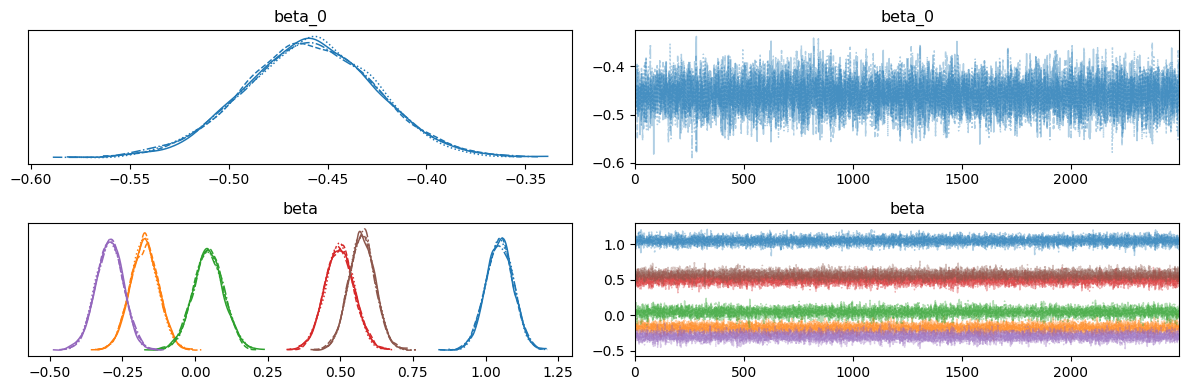

In [39]:
# Traceplots and marginals - visual convergence checks
axarr = az.plot_trace(fit, var_names=["beta_0", "beta"])
plt.tight_layout()

# Predictive Model Accuracy

In [40]:
# extracting the predicted probabilities for the test set...
p_hat_samples = fit.stan_variable("p_hat")

# calculating mean predicted probability...
p_bar = p_hat_samples.mean(axis=0)

# brier score (as taken from hw pdf)...
brier_score = ((p_bar - y_test.to_numpy())**2).mean()

# calculating accuracy on the test set...
predictions = (p_bar > 0.5).astype(int)
accuracy = (predictions == y_test.to_numpy()).mean()

print(f"Brier Score: {brier_score:.4f}")
print(f"Test Set Accuracy: {accuracy:.2%}")

Brier Score: 0.1643
Test Set Accuracy: 75.14%


# Generative Model Accuracy

In [41]:
# extracing simulated decisions from fitted model...
y_sim_samples = fit.stan_variable("y_sim")

# calculating the "yes" rates for ground truth and our model...
gt_yes = y_test.mean()
y_sim_yes = y_sim_samples.mean()

abs_err = abs(gt_yes - y_sim_yes)
print(f"Ground Truth Yes Rate: {gt_yes:.2%}")
print(f"Simulated Yes Rate: {y_sim_yes:.2%}")
print(f"Posterior Predictive Error: {abs_err:.4f}")


Ground Truth Yes Rate: 42.97%
Simulated Yes Rate: 42.21%
Posterior Predictive Error: 0.0076
